<a href="https://colab.research.google.com/github/deadshot002/Machine-Learning-Based-Capacitor-Health-Classification-using-XGBoosst/blob/main/CapacitorHealthMonitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download programmer3/cvt-dielectric-loss-measurements

Dataset URL: https://www.kaggle.com/datasets/programmer3/cvt-dielectric-loss-measurements
License(s): CC0-1.0
cvt-dielectric-loss-measurements.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cvt-dielectric-loss-measurements.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("/content/CVT_DielectricLoss_Dataset.csv")

In [ ]:
df

,Time_s,V_primary_kV,V_secondary_kV,Dielectric_Loss,Temperature_C,Humidity_%,Load_Current_A,Insulation_Status
0,0,110.248357,10.447654,0.002018,35.121829,62.336211,101.570370,0
1,1,109.993689,10.533115,0.002271,34.486310,62.445975,96.570289,0
2,2,110.449425,10.571843,0.002039,34.570052,62.360206,101.680713,0
3,3,110.949732,10.554769,0.001906,34.609341,63.568282,99.909186,0
4,4,110.133590,10.574869,0.001998,35.180849,63.039969,101.916724,0
...,...,...,...,...,...,...,...,...
1395,1395,109.779471,10.426292,0.004740,34.285532,57.312677,99.382824,1
1396,1396,109.075770,10.503590,0.004902,35.330300,58.351378,99.332448,1
1397,1397,109.325976,10.391885,0.004637,34.955877,57.027356,97.711430,1
1398,1398,110.474626,10.469460,0.004495,35.119519,57.522640,98.620742,1


In [ ]:
df = df.iloc[:,1:]

In [ ]:
df

,V_primary_kV,V_secondary_kV,Dielectric_Loss,Temperature_C,Humidity_%,Load_Current_A,Insulation_Status
0,110.248357,10.447654,0.002018,35.121829,62.336211,101.570370,0
1,109.993689,10.533115,0.002271,34.486310,62.445975,96.570289,0
2,110.449425,10.571843,0.002039,34.570052,62.360206,101.680713,0
3,110.949732,10.554769,0.001906,34.609341,63.568282,99.909186,0
4,110.133590,10.574869,0.001998,35.180849,63.039969,101.916724,0
...,...,...,...,...,...,...,...
1395,109.779471,10.426292,0.004740,34.285532,57.312677,99.382824,1
1396,109.075770,10.503590,0.004902,35.330300,58.351378,99.332448,1
1397,109.325976,10.391885,0.004637,34.955877,57.027356,97.711430,1
1398,110.474626,10.469460,0.004495,35.119519,57.522640,98.620742,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   V_primary_kV       1400 non-null   float64
 1   V_secondary_kV     1400 non-null   float64
 2   Dielectric_Loss    1400 non-null   float64
 3   Temperature_C      1400 non-null   float64
 4   Humidity_%         1400 non-null   float64
 5   Load_Current_A     1400 non-null   float64
 6   Insulation_Status  1400 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 76.7 KB


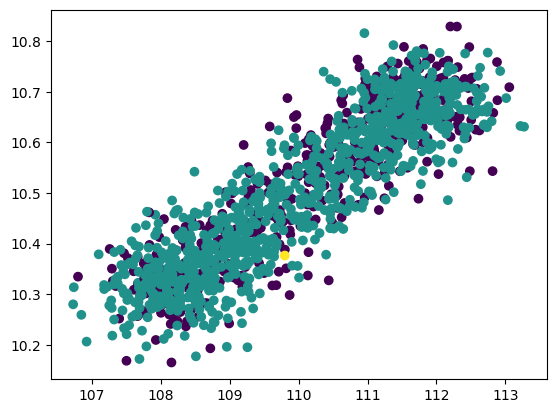

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['V_primary_kV'],df['V_secondary_kV'],c=df['Insulation_Status'])

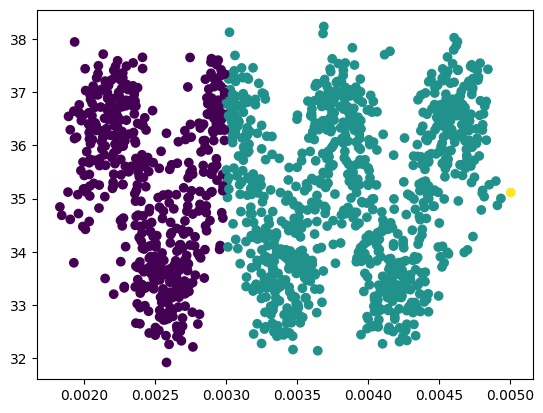

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Dielectric_Loss'],df['Temperature_C'],c=df['Insulation_Status'])

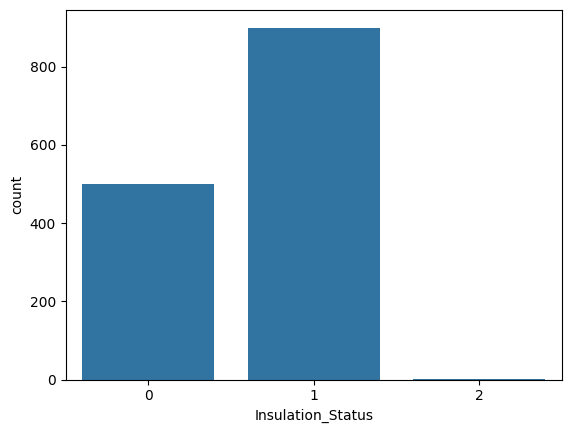

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Insulation_Status', data=df)
plt.show()

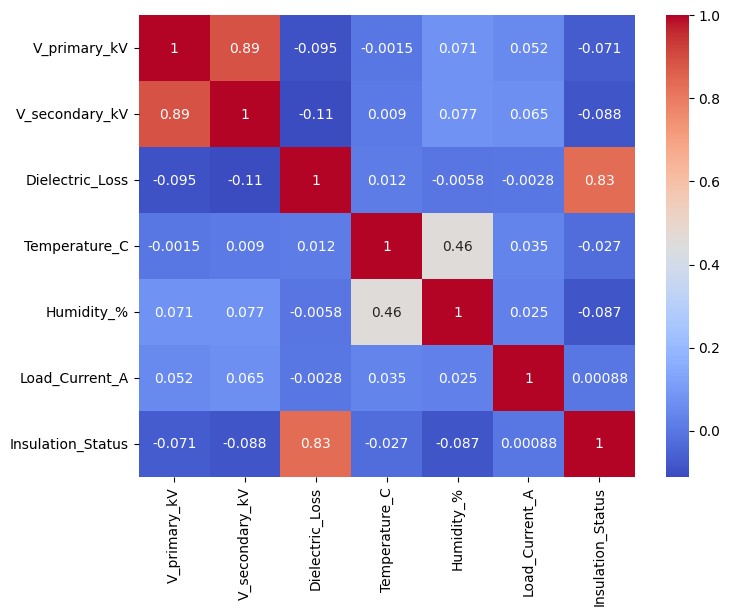

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

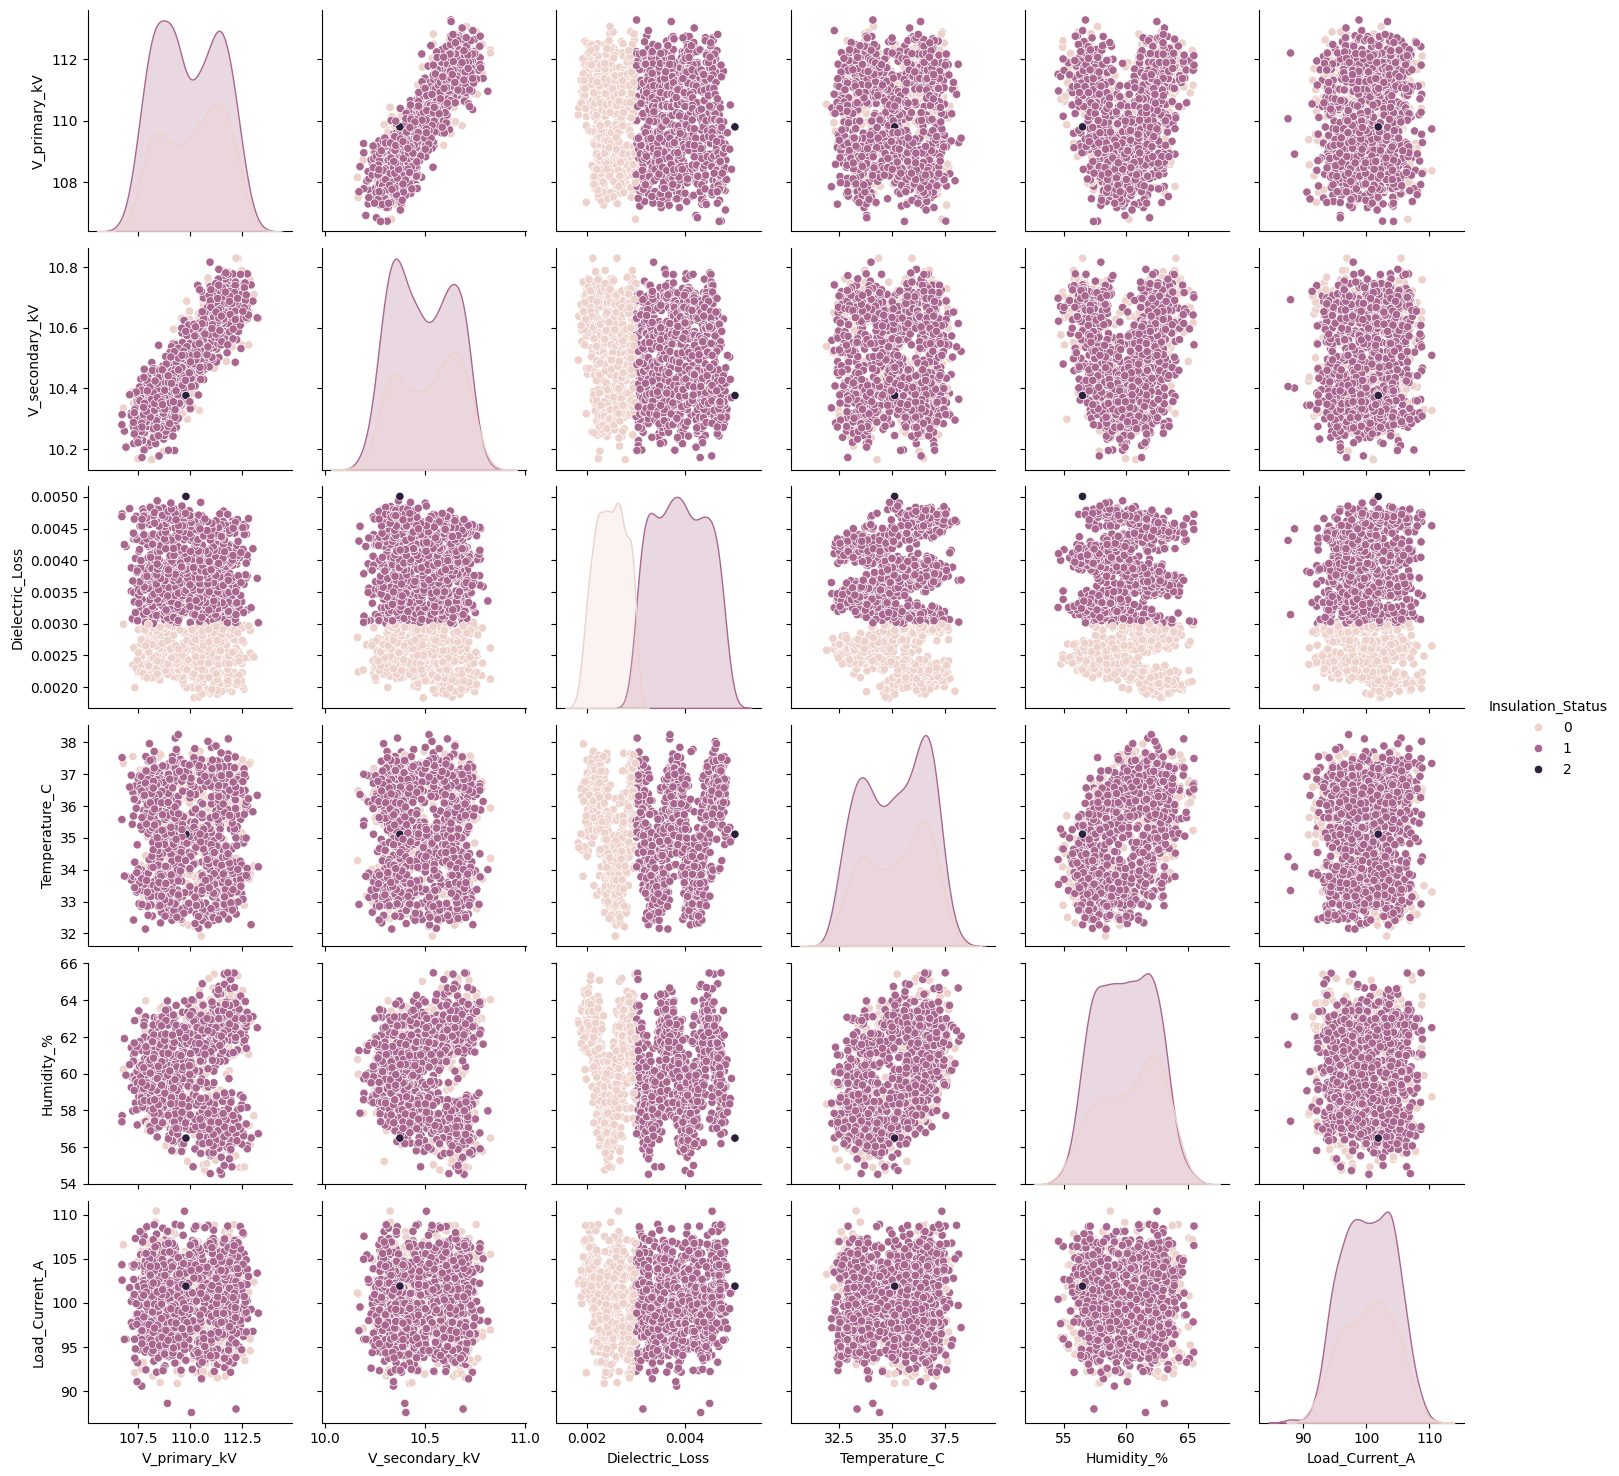

In [ ]:
sns.pairplot(df, hue='Insulation_Status')

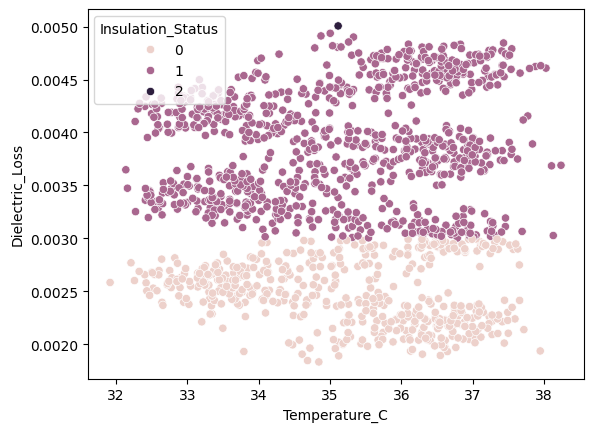

In [ ]:
sns.scatterplot(
    data=df,
    x='Temperature_C',
    y='Dielectric_Loss',
    hue='Insulation_Status'
)
plt.show()

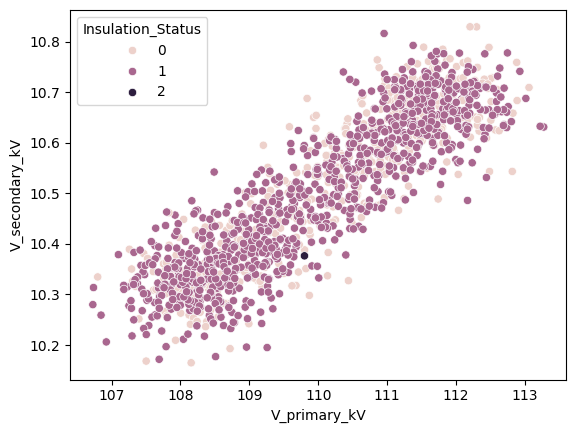

In [ ]:
sns.scatterplot(
    data=df,
    x='V_primary_kV',
    y='V_secondary_kV',
    hue='Insulation_Status'
)
plt.show()

In [ ]:
X = df.drop('Insulation_Status', axis=1)
y = df['Insulation_Status']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Insulation_Status', axis=1)
y = df['Insulation_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9964285714285714


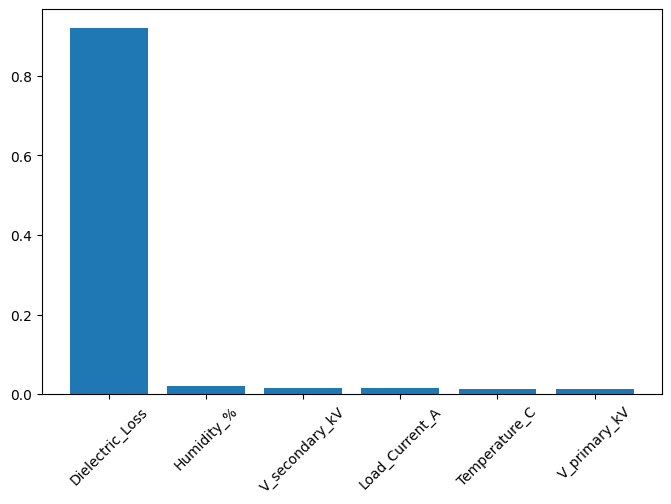

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head()

,V_primary_kV,V_secondary_kV,Dielectric_Loss,Temperature_C,Humidity_%,Load_Current_A,Insulation_Status
0,110.248357,10.447654,0.002018,35.121829,62.336211,101.570370,0
1,109.993689,10.533115,0.002271,34.486310,62.445975,96.570289,0
2,110.449425,10.571843,0.002039,34.570052,62.360206,101.680713,0
3,110.949732,10.554769,0.001906,34.609341,63.568282,99.909186,0
4,110.133590,10.574869,0.001998,35.180849,63.039969,101.916724,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   V_primary_kV       1399 non-null   float64
 1   V_secondary_kV     1399 non-null   float64
 2   Dielectric_Loss    1399 non-null   float64
 3   Temperature_C      1399 non-null   float64
 4   Humidity_%         1399 non-null   float64
 5   Load_Current_A     1399 non-null   float64
 6   Insulation_Status  1399 non-null   float64
 7   output             1 non-null      float64
dtypes: float64(8)
memory usage: 87.6 KB


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv("/content/CVT_DielectricLoss_Dataset.csv")

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Remove columns that contain only zeros
df = df.loc[:, (df != 0).any(axis=0)]

print(df.shape)

(1400, 8)


In [ ]:
from xgboost import XGBClassifier

X = df.drop("Insulation_Status", axis=1)
y = df["Insulation_Status"]

model = XGBClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.00427752 0.00281274 0.0049694  0.9747728  0.00199819 0.0043822
 0.00678719]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

wrong = X_test[pred != y_test]
print("Potential suspicious records:")
print(wrong.head())

Potential suspicious records:
      Time_s  V_primary_kV  V_secondary_kV  Dielectric_Loss  Temperature_C  \
1386    1386    109.799312       10.376344         0.005007      35.114116   

      Humidity_%  Load_Current_A  
1386   56.487604        101.8955  


In [ ]:
wrong_idx = X_test[pred != y_test].index

comparison = pd.DataFrame({
    'Actual': y_test.loc[wrong_idx],
    'Predicted': pred[pred != y_test]
})

print(comparison.head())

      Actual  Predicted
1386       2          1


In [ ]:
df.iloc[1380:1390]

,Time_s,V_primary_kV,V_secondary_kV,Dielectric_Loss,Temperature_C,Humidity_%,Load_Current_A,Insulation_Status
1380,1380,109.163392,10.426169,0.004788,36.568168,56.784587,99.576910,1
1381,1381,108.631878,10.355095,0.004711,36.099609,59.373240,99.861567,1
1382,1382,110.007001,10.332675,0.004679,36.379753,57.751151,99.310140,1
1383,1383,108.679060,10.346089,0.004708,35.723310,57.321052,101.487175,1
1384,1384,109.407540,10.379289,0.004720,36.081135,56.703838,99.125505,1
1385,1385,109.241665,10.391606,0.004806,35.104908,57.368713,95.840124,1
1386,1386,109.799312,10.376344,0.005007,35.114116,56.487604,101.895500,2
1387,1387,109.986460,10.355765,0.004702,34.036004,59.947831,99.255473,1
1388,1388,109.279753,10.403569,0.004734,35.967835,57.801593,97.216774,1
1389,1389,108.945815,10.441324,0.004772,36.114020,57.733908,95.769982,1


<Axes: xlabel='Insulation_Status', ylabel='Dielectric_Loss'>

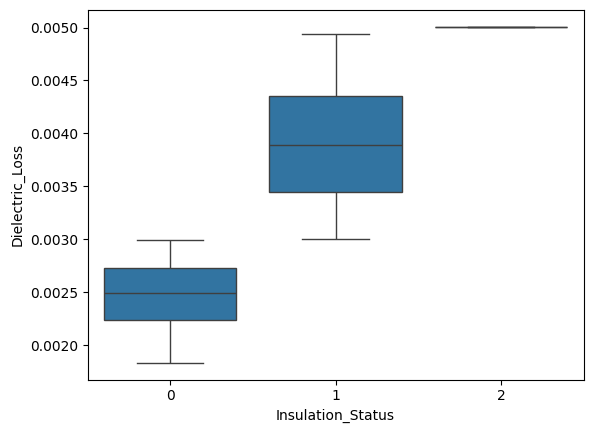

In [ ]:
import seaborn as sns

sns.boxplot(x='Insulation_Status', y='Dielectric_Loss', data=df)

In [ ]:
probs = model.predict_proba(X_test)

idx = list(X_test.index).index(1386)

print(probs[idx])

[6.3635549e-04 9.9936360e-01 5.2559315e-08]


In [ ]:
df.iloc[1386]

,1386
Time_s,1386.000000
V_primary_kV,109.799312
V_secondary_kV,10.376344
Dielectric_Loss,0.005007
Temperature_C,35.114116
Humidity_%,56.487604
Load_Current_A,101.895500
Insulation_Status,1.000000


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("CVT_DielectricLoss_Dataset.csv")

df['Insulation_Status'] = df['Insulation_Status'].replace(2, 1)

# Features and target
X = df[['V_primary_kV',
        'V_secondary_kV',
        'Dielectric_Loss',
        'Temperature_C',
        'Humidity_%',
        'Load_Current_A']]

y = df['Insulation_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost Binary Classifier
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       180

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280


Confusion Matrix:
[[100   0]
 [  0 180]]


In [80]:
import pickle
pickle.dump(model,open('model.pkl','wb'))